In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../outputs_k2/k2-fourier-cometcurve2.txt',sep=' ',header=None)

In [3]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,/storage/astro2/phrdhx/k2/everest/c16/hlsp_eve...,EPIC,251278467,-34.56914,-26.94498,3281.73754,-3.00000,-3.00000,-3.00000,-3.00000,...,943,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,noModelFitted
1,/storage/astro2/phrdhx/k2/everest/c16/hlsp_eve...,EPIC,211640715,-62.04177,-42.86584,3264.49085,-3.00000,-3.00000,-3.00000,-3.00000,...,99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,noModelFitted
2,/storage/astro2/phrdhx/k2/everest/c08/hlsp_eve...,EPIC,220382868,-52.85872,-52.85234,2615.88856,-3.00000,-3.00000,-3.00000,-3.00000,...,2781,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,noModelFitted
3,/storage/astro2/phrdhx/k2/everest/c05/hlsp_eve...,EPIC,211974565,-12.34961,-3.35724,2309.55328,-2.00000,-2.00000,-2.00000,-2.00000,...,144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,end
4,/storage/astro2/phrdhx/k2/everest/c08/hlsp_eve...,EPIC,220214845,-30.48462,-17.41115,2588.38816,1.20016,40.88722,0.05017,-2.63041,...,1435,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,maybeTransit


In [17]:
cols = [
    'path',
    'catalogue',
    'EPIC_ID',
    'signal',
    'snr',
    'time',
    'asym_score',
    'amplitude',
    'width',
    'skewness',
    'skewness_err',
    'duration',
    'depth',
    'peak_lspower',
    'mstat',
    'm',
    'n',
    'chisq_gauss',
    'chisq_skew',
    'rchisq_gauss',
    'rchisq_skew',
    'rmse_gauss',
    'rmse_skew',
    'mae_gauss',
    'mae_skew',
    'transit_prob'

    
]

In [18]:
data.columns = cols

In [21]:
data = data[data.transit_prob == 'maybeTransit']
print(len(data))
test = data[abs(data.snr) > 5]

96344


In [23]:
import os
os.chdir('../scripts/')
from analysis_tools_cython import *

['TIME', 'FLUX', 'QUALITY', 'FRAW_ERR']


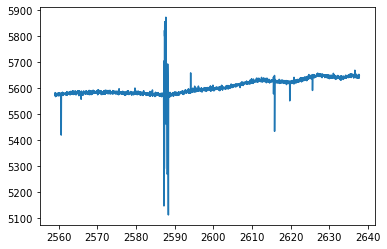

['TIME', 'FLUX', 'QUALITY', 'FRAW_ERR']


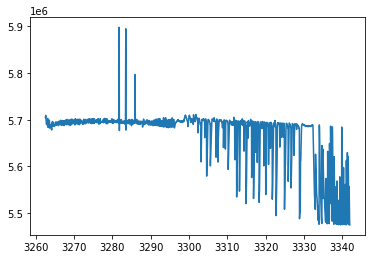

['TIME', 'FLUX', 'QUALITY', 'FRAW_ERR']


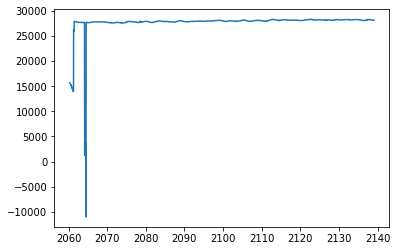

['TIME', 'FLUX', 'QUALITY', 'FRAW_ERR']


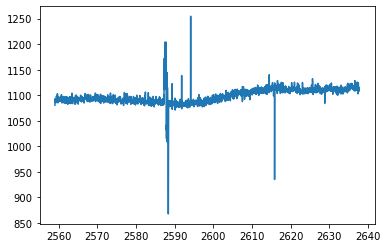

['TIME', 'FLUX', 'QUALITY', 'FRAW_ERR']


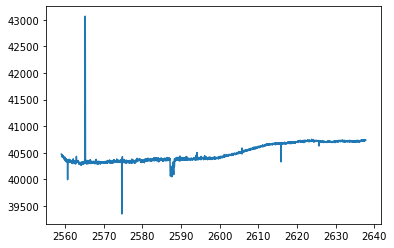

In [27]:
for i in test.path[0:5]:
    lc, info = import_lightcurve(i, pipeline='K2',flux='FCOR')
    print(lc.colnames)
    plt.plot(lc['TIME'],lc['FLUX'])
    plt.show()

In [28]:
import lightkurve as lk

In [29]:
test.head()

,path,catalogue,EPIC_ID,signal,snr,time,asym_score,amplitude,width,skewness,...,n,chisq_gauss,chisq_skew,rchisq_gauss,rchisq_skew,rmse_gauss,rmse_skew,mae_gauss,mae_skew,transit_prob
4,/storage/astro2/phrdhx/k2/everest/c08/hlsp_eve...,EPIC,220214845,-30.48462,-17.41115,2588.38816,1.20016,40.88722,0.05017,-2.63041,...,1435,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,maybeTransit
9,/storage/astro2/phrdhx/k2/everest/c16/hlsp_eve...,EPIC,212048998,-15.06477,-5.43162,3328.98531,2.94254,66062.06208,0.24075,29.87592,...,3255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,maybeTransit
10,/storage/astro2/phrdhx/k2/everest/c02/hlsp_eve...,EPIC,203508374,-47.68214,-12.99938,2064.32952,3.84767,11029.99553,0.14873,-0.02425,...,198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,maybeTransit
11,/storage/astro2/phrdhx/k2/everest/c08/hlsp_eve...,EPIC,220215948,-31.92552,-17.15638,2588.38782,1.01339,16.18625,0.05204,-2.99634,...,1435,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,maybeTransit
14,/storage/astro2/phrdhx/k2/everest/c08/hlsp_eve...,EPIC,220686828,-16.35486,-5.21024,2587.71424,1.26615,231.86732,0.38598,-0.00059,...,1402,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,maybeTransit


In [34]:
lc = lk.search_lightcurve('EPIC 220214845',campaign=8,mission='K2',author='EVEREST').download()

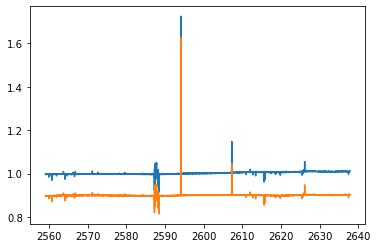

In [36]:
plt.plot(lc.time.value,lc.flux.value/np.nanmedian(lc.fcor.value))
plt.plot(lc.time.value,lc.fcor.value/np.nanmedian(lc.fcor.value)-0.1)
plt.show()